A Convolutional Neural Network (CNN) is a type of deep learning model designed to work with images.It learns directly from image pixels by scanning the image with small filters and automatically finding useful visual patterns such as edges, shapes, textures and important image features. We install the necessary dependencies.

In [ ]:
!pip install scikit-learn
import tensorflow as tf
from tensorflow.keras.layers import Dense, Conv2D, Dropout, MaxPooling2D, Flatten
from tensorflow.keras.models import Sequential
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
import numpy as np

Defaulting to user installation because normal site-packages is not writeable


I0000 00:00:1779876875.462709 1881301 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1779876878.207484 1881301 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1779876893.683474 1881301 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


This block prepares the chest X-ray images for CNN training. First, pixel values are normalized from 0–255 to 0–1 for more stable learning. Data augmentation is then applied to the training images by rotating, shifting, zooming and flipping them, which creates slightly different versions of the same X-rays. This increases data diversity, reduces overfitting and helps the CNN generalise better to unseen images. Twenty percent of the training data is reserved for validation. Validation and test images are only rescaled without augmentation to keep evaluation fair. Finally, the generators load the images from folders in batches of 32, resize them to 150×150 pixels and convert them to grayscale before feeding them into the CNN.

In [ ]:
train_dir = '/gpfs/mariana/smbgroup/IHB0002/chest_xray2017/chest_xray/train'
test_dir  = '/gpfs/mariana/smbgroup/IHB0002/chest_xray2017/chest_xray/test'

# Training data with augmentation + 20% held out for validation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Validation: no augmentation, same 20% split
val_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

# Test: no augmentation
test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir, target_size=(150, 150), batch_size=32,
    class_mode='categorical', color_mode='grayscale', subset='training'
)
val_generator = val_datagen.flow_from_directory(
    train_dir, target_size=(150, 150), batch_size=32,
    class_mode='categorical', color_mode='grayscale', subset='validation'
)
test_generator = test_datagen.flow_from_directory(
    test_dir, target_size=(150, 150), batch_size=32,
    class_mode='categorical', color_mode='grayscale', shuffle=False
)

Found 4187 images belonging to 2 classes.
Found 1045 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


We define the CNN model used to classify chest X-ray images into NORMAL or PNEUMONIA. The input images are grayscale with size 150 × 150 × 1. The model uses three Conv2D layers with 3 × 3 filters, where 3pixels by 3pixels being the size —starting with 32 filters and then 64 filters in deeper layers to learn more complex features. The first layer learns simple patterns such as edges and contrast, while deeper layers learn more complex lung features linked to pneumonia. After each convolution, MaxPooling (2 × 2) reduces image size, keeps the strongest features and lowers computation, which also helps reduce overfitting. The Flatten layer converts the extracted feature maps into a one-dimensional vector, and the Dense/output layers use this information to classify the image. ReLU activation helps the network learn non-linear patterns, while Softmax produces the final probability for each class.

If the model is too slow, I would reduce the image size, reduce the number of filters, or use fewer dense units. For example, changing the dense layer from 64 units to 32 units would reduce the number of trainable parameters and make training faster.

In [ ]:
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(150, 150, 1)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    Flatten(),
    Dense(64, activation='relu'),
    Dense(2, activation='softmax')   # 2 outputs: NORMAL and PNEUMONIA
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

/gpfs/mariana/home/samuea/.local/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
E0000 00:00:1779876912.877368 1881301 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 73984)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     4,735,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,790,914 (18.28 MB)

 Trainable params: 4,790,914 (18.28 MB)

 Non-trainable params: 0 (0.00 B)

CNN starts to train using model.fit(). The train_generator feeds batches of chest X-ray images into the model, while epochs=30 means the CNN passes through the full training dataset 30 times to improve learning. After each epoch, validation_data=val_generator checks performance on unseen validation images to monitor how well the model generalises. The history variable stores the training results, including accuracy, loss, validation accuracy and validation loss, so they can be analysed and plotted later.

In [ ]:

history = model.fit(
    train_generator,
    epochs=30,
    validation_data=val_generator
)

Epoch 1/30


I0000 00:00:1779876915.359084 1881301 generator_dataset_op.cc:213] Memory patch applied: M_TRIM_THRESHOLD=128 kb was set.


131/131 ━━━━━━━━━━━━━━━━━━━━ 125s 948ms/step - accuracy: 0.7533 - loss: 0.5383 - val_accuracy: 0.8373 - val_loss: 0.3300
Epoch 2/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 60s 457ms/step - accuracy: 0.8629 - loss: 0.3142 - val_accuracy: 0.8813 - val_loss: 0.2875
Epoch 3/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 59s 454ms/step - accuracy: 0.8949 - loss: 0.2603 - val_accuracy: 0.8823 - val_loss: 0.2614
Epoch 4/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 60s 455ms/step - accuracy: 0.8870 - loss: 0.2607 - val_accuracy: 0.8804 - val_loss: 0.2733
Epoch 5/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 59s 446ms/step - accuracy: 0.8973 - loss: 0.2412 - val_accuracy: 0.9234 - val_loss: 0.1854
Epoch 6/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 58s 442ms/step - accuracy: 0.9090 - loss: 0.2310 - val_accuracy: 0.8976 - val_loss: 0.2696
Epoch 7/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 59s 452ms/step - accuracy: 0.9209 - loss: 0.2081 - val_accuracy: 0.9225 - val_loss: 0.1947
Epoch 8/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 58s 444ms/step - accuracy: 0.9219 - loss: 0.2006 - va

Plots training and validation Loss and accuracy against each epoch. Higher training accuracy and lower loss is better. Similarly for validation and test data, how well the model generalises on unseen data.

A small sign of overfitting starts around epoch 11. This can be seen because the training loss continues decreasing smoothly, but the validation loss begins to fluctuate and occasionally increases. At the same time training accuracy keeps rising while validation accuracy becomes less stable. The gap is not large, so overfitting is mild rather than severe.

 Dropout improves generalization by reducing false positives, and transfer learning with Xception as well. We can also train for more epochs and improve model complexity.

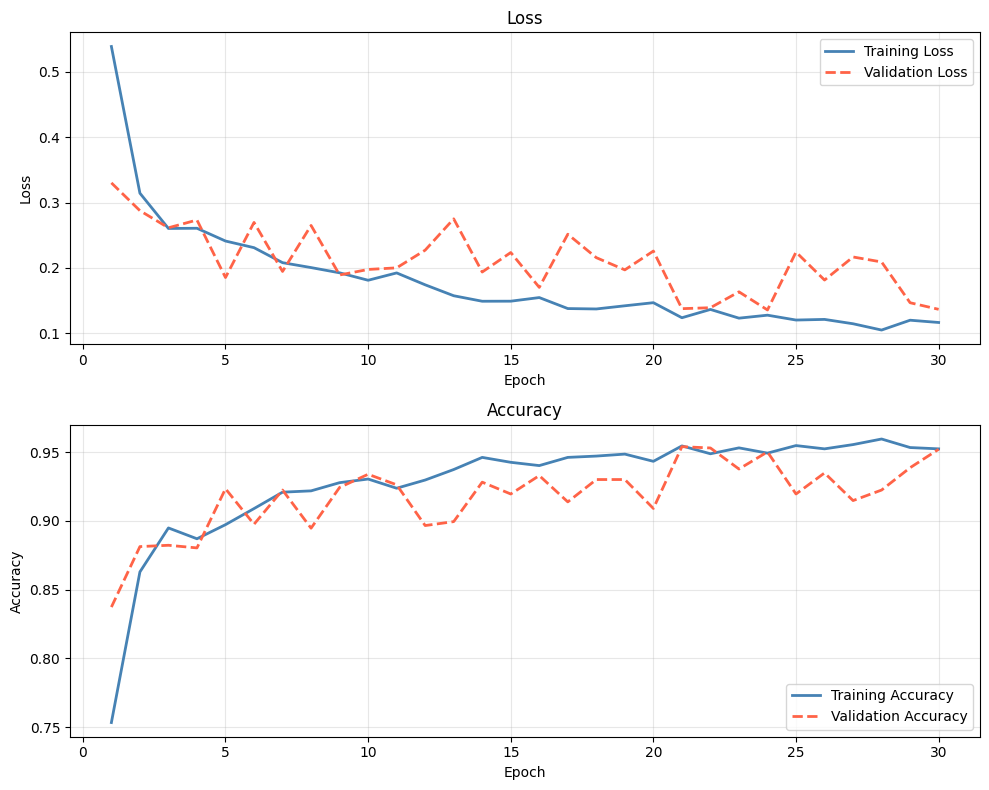

In [ ]:
epochs_range = range(1, len(history.history['loss']) + 1)

fig, ax = plt.subplots(2, 1, figsize=(10, 8))

# Loss
ax[0].plot(epochs_range, history.history['loss'],     color='steelblue', linewidth=2, label='Training Loss')
ax[0].plot(epochs_range, history.history['val_loss'], color='tomato',    linewidth=2, linestyle='--', label='Validation Loss')
ax[0].set_title('Loss'); ax[0].set_xlabel('Epoch'); ax[0].set_ylabel('Loss')
ax[0].legend(); ax[0].grid(True, alpha=0.3)

# Accuracy
ax[1].plot(epochs_range, history.history['accuracy'],     color='steelblue', linewidth=2, label='Training Accuracy')
ax[1].plot(epochs_range, history.history['val_accuracy'], color='tomato',    linewidth=2, linestyle='--', label='Validation Accuracy')
ax[1].set_title('Accuracy'); ax[1].set_xlabel('Epoch'); ax[1].set_ylabel('Accuracy')
ax[1].legend(loc='lower right'); ax[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
loss, accuracy = model.evaluate(test_generator)
print(f"Test accuracy: {accuracy:.4f}")
print(f"Test loss:     {loss:.4f}")

20/20 ━━━━━━━━━━━━━━━━━━━━ 9s 437ms/step - accuracy: 0.8494 - loss: 0.3576
Test accuracy: 0.8494
Test loss:     0.3576


Code evaluates the trained CNN using a confusion matrix on the test set. First, y_true = test_generator.classes gets the real labels for each chest X-ray. Then model.predict(test_generator) generates prediction probabilities for each class. np.argmax(..., axis=1) selects the class with the highest probability as the final prediction (NORMAL or PNEUMONIA). The confusion matrix then compares predicted labels with the true labels and shows how many images were correctly classified and how many were misclassified. ConfusionMatrixDisplay plots the matrix with class labels, making it easier to interpret the model’s performance and identify false positives and false negatives. From the confusion matrix, the model missed 20 pneumonia cases (false negatives), meaning patients with pneumonia were predicted as normal. It also produced 74 false alarms (false positives), meaning normal chest X-rays were predicted as pneumonia. Clinically, false negatives are more serious because missed pneumonia may delay treatment, while false positives usually lead to additional checks but are safer than missing a real infection.

20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 136ms/step


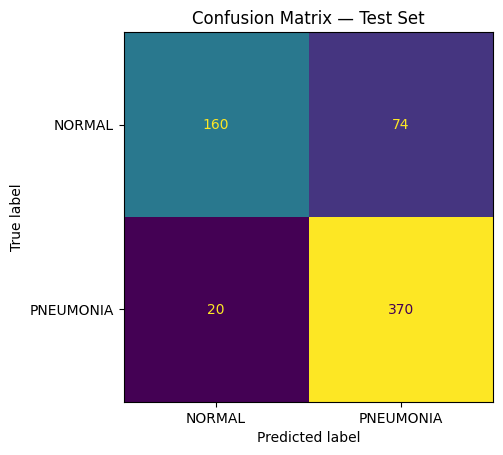

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Get true labels
y_true = test_generator.classes

# Get model predictions (probability for each class)
y_pred_probs = model.predict(test_generator)

# Take the class with the highest probability
y_pred = np.argmax(y_pred_probs, axis=1)

# Build and plot confusion matrix
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['NORMAL', 'PNEUMONIA'])
disp.plot(colorbar=False)
plt.title('Confusion Matrix — Test Set')
plt.show()

Here Lower sensitivity value causes alarm which means increased FN(missed pneumonia cases) from TP/(TP+FN), also many FPs and FNs may reduce accuracy. Adjusting the decision threshold changes how strict the CNN is when deciding whether an X-ray shows pneumonia. A lower threshold makes the model predict pneumonia more often, which increases sensitivity and reduces missed pneumonia cases (false negatives), but it also creates more false alarms (false positives), so specificity decreases. A higher threshold makes the model more strict before predicting pneumonia, which improves specificity and reduces false positives, but sensitivity decreases and more pneumonia cases may be missed. For pneumonia screening, a lower threshold is usually preferred because catching as many real pneumonia cases as possible is more important than avoiding extra false alarms. I will deploy this model as it has lower FN value. Clinical implication for sensitivity-“Out of all patients with pneumonia, how many did the model correctly find?”, for specificity, spec = tn / (tn + fp). Clinically, Out of all normal patients, how many were correctly identified?”

In [ ]:
# Extract values from confusion matrix
# cm[0,0] = TN,  cm[0,1] = FP
# cm[1,0] = FN,  cm[1,1] = TP
TN, FP = cm[0, 0], cm[0, 1]
FN, TP = cm[1, 0], cm[1, 1]

sensitivity  = TP / (TP + FN)
specificity  = TN / (TN + FP)
accuracy_man = (TP + TN) / (TP + TN + FP + FN)

print(f"True Positives  (TP) — pneumonia correctly detected: {TP}")
print(f"False Negatives (FN) — pneumonia missed:            {FN}")
print(f"True Negatives  (TN) — healthy correctly cleared:   {TN}")
print(f"False Positives (FP) — healthy flagged as sick:     {FP}")
print()
print(f"Sensitivity  (recall): {sensitivity:.3f}")
print(f"Specificity:           {specificity:.3f}")
print(f"Accuracy:              {accuracy_man:.3f}")

True Positives  (TP) — pneumonia correctly detected: 370
False Negatives (FN) — pneumonia missed:            20
True Negatives  (TN) — healthy correctly cleared:   160
False Positives (FP) — healthy flagged as sick:     74

Sensitivity  (recall): 0.949
Specificity:           0.684
Accuracy:              0.849


Predicted pneumonia compared against thresholds to decide whether its pneumonia or not, pneumonia_probs>=t, if its actually greater than and the true label was pneumonia then, we have a True positve (TP), if pneumonia_probs<t, then a normal case but should the true label be a normal case then (TN) but should the true label be a pneumonia then a false negative (FN).

Now we have a graph of True Positive rate(TPR) against False Positve rate (FPR)The straight means model randomly guesses if has not learned useful features to distinguish pneumonia from normal. in our case model does well as it pushes to corner, Higher TPR and stays above the diagonal reference line. Each point on the curve represents a different threshold.

With an AUC = 0.933, which is very strong performance, close to 1 means the model separates the two classes well, while 0.5 would mean random prediction. Therefore, an AUC of 0.933 suggests the CNN has a high ability to correctly rank pneumonia cases higher than normal cases.

 Threshold   Missed (FN)   False alarms (FP)   Sensitivity   Specificity
------------------------------------------------------------------------
      0.90            91                  20         0.767         0.915
      0.70            37                  42         0.905         0.821
      0.50            20                  74         0.949         0.684 ← default
      0.30             7                 107         0.982         0.543
      0.10             2                 182         0.995         0.222
      0.05             0                 206         1.000         0.120


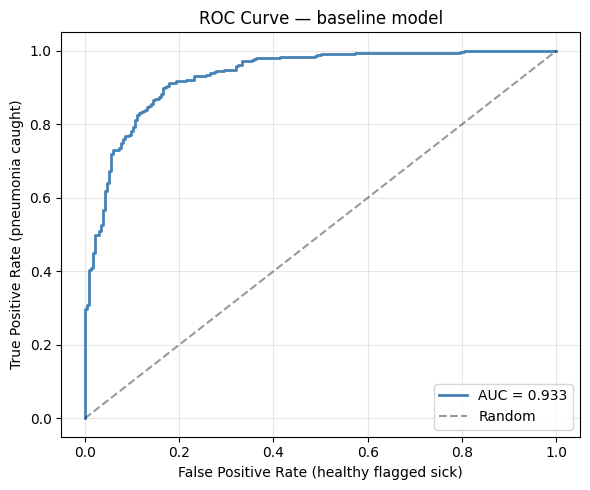

AUC = 0.933 — every point on the curve is a different threshold


In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score

# Extract the PNEUMONIA probability column
pneumonia_probs = y_pred_probs[:, 1]

# Sweep across thresholds and print the tradeoff table
print(f"{'Threshold':>10}  {'Missed (FN)':>12}  {'False alarms (FP)':>18}  {'Sensitivity':>12}  {'Specificity':>12}")
print("-" * 72)
for t in [0.9, 0.7, 0.5, 0.3, 0.1, 0.05]:
    pred = (pneumonia_probs >= t).astype(int)
    fn = ((pred == 0) & (y_true == 1)).sum()
    fp = ((pred == 1) & (y_true == 0)).sum()
    tn = ((pred == 0) & (y_true == 0)).sum()
    tp = ((pred == 1) & (y_true == 1)).sum()
    sens = tp / (tp + fn) if (tp + fn) > 0 else 0
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0
    marker = " ← default" if t == 0.5 else ""
    print(f"{t:>10.2f}  {fn:>12}  {fp:>18}  {sens:>12.3f}  {spec:>12.3f}{marker}")

# ROC curve
fpr, tpr, thresholds = roc_curve(y_true, pneumonia_probs)
auc = roc_auc_score(y_true, pneumonia_probs)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='steelblue', linewidth=2, label=f'AUC = {auc:.3f}')
plt.plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Random')
plt.xlabel('False Positive Rate (healthy flagged sick)')
plt.ylabel('True Positive Rate (pneumonia caught)')
plt.title('ROC Curve — baseline model')
plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print(f"AUC = {auc:.3f} — every point on the curve is a different threshold")

In [ ]:
#Rebuild with dropout

With Dropout layers, we may reduce overfitting and improve generalisation on unseen chest X-rays. Dropout randomly switches off a percentage of neurons during training (50% and 30% here), forcing the network to learn more robust image features instead of memorising the training data. This is especially useful in the dense layers, where many trainable parameters increase the risk of overfitting. The goal is better validation and test performance on new pneumonia images. After rebuilding the CNN with dropout and trained Xception, sensitivity changed from 0.949 to 0.938, while specificity improved from 0.684 to 0.842. This means the model became slightly less sensitive and missed a few more pneumonia cases, but it became much better at identifying healthy patients correctly and reduced false positives suggesting dropout reduced overfitting and improved generalisation. In this case, the new model gives a better balance between detecting pneumonia and avoiding unnecessary false alarms.



A test accuracy of 0.9022 was achieved, compared with 0.8494 for the original CNN. This improvement shows that transfer learning with pretrained Xception features helped the model recognise chest X-ray patterns more effectively than the baseline CNN. The pretrained network starts from strong image features learned on a very large dataset, so it can adapt faster and classify pneumonia more accurately. Xception delivered the highest overall test accuracy and strongest generalisation performance.

In [ ]:
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(150, 150, 1)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    Flatten(),
    Dropout(0.5),    # ← new: randomly switch off 50% of neurons during training
    Dense(64, activation='relu'),
    Dropout(0.3),    # ← new: randomly switch off 30% of neurons during training
    Dense(2, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

history = model.fit(
    train_generator,
    epochs=20,
    validation_data=val_generator
)

/gpfs/mariana/home/samuea/.local/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 61s 456ms/step - accuracy: 0.7812 - loss: 0.4751 - val_accuracy: 0.9062 - val_loss: 0.2140
Epoch 2/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 57s 435ms/step - accuracy: 0.8717 - loss: 0.3012 - val_accuracy: 0.8306 - val_loss: 0.3423
Epoch 3/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 58s 444ms/step - accuracy: 0.8801 - loss: 0.2857 - val_accuracy: 0.8842 - val_loss: 0.2550
Epoch 4/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 58s 444ms/step - accuracy: 0.8978 - loss: 0.2475 - val_accuracy: 0.9196 - val_loss: 0.1904
Epoch 5/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 58s 445ms/step - accuracy: 0.8920 - loss: 0.2526 - val_accuracy: 0.9167 - val_loss: 0.1968
Epoch 6/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 58s 441ms/step - accuracy: 0.9100 - loss: 0.2315 - val_accuracy: 0.9244 - val_loss: 0.2015
Epoch 7/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 58s 445ms/step - accuracy: 0.9085 - loss: 0.2236 - val_accuracy: 0.8900 - val_loss: 0.2553
Epoch 8/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 58s 442ms/step - accuracy: 0.9159 - loss: 0

In [ ]:
#Reload Data generators in RGB


Data generators reloaded in RGB as the Xception transfer-learning model requires 3-channel input images. Chest X-rays are grayscale, converting them to RGB duplicates the same intensity across the red, green and blue channels, allowing the pretrained Xception model to accept the images while preserving the original visual information.

In [ ]:
train_generator_rgb = train_datagen.flow_from_directory(
    train_dir, target_size=(150, 150), batch_size=32,
    class_mode='categorical', color_mode='rgb', subset='training'
)
val_generator_rgb = val_datagen.flow_from_directory(
    train_dir, target_size=(150, 150), batch_size=32,
    class_mode='categorical', color_mode='rgb', subset='validation'
)
test_generator_rgb = test_datagen.flow_from_directory(
    test_dir, target_size=(150, 150), batch_size=32,
    class_mode='categorical', color_mode='rgb', shuffle=False
)

Found 4187 images belonging to 2 classes.
Found 1045 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


In [ ]:
#Build the transfer Learning Model

In [ ]:
#Define the model
from tensorflow.keras.applications import Xception
from tensorflow.keras.layers import GlobalAveragePooling2D

# Load Xception without its original top classification layer
base_model = Xception(
    include_top=False,
    weights="imagenet",
    input_shape=(150, 150, 3)
)

# Freeze all pre-trained weights — we do not update them during training
base_model.trainable = False

# Add our own small classification head on top
model_xception = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(32, activation='relu'),
    Dense(2,  activation='softmax')
])

model_xception.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model_xception.summary()

83683744/83683744 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step 


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ xception (Functional)           │ (None, 5, 5, 2048)     │    20,861,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │        65,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 2)              │            66 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,927,114 (79.83 MB)

 Trainable params: 65,634 (256.38 KB)

 Non-trainable params: 20,861,480 (79.58 MB)

In [ ]:
#Train the model
history_xception = model_xception.fit(
    train_generator_rgb,
    epochs=10,       # fewer epochs needed — we start from strong weights
    validation_data=val_generator_rgb
)

Epoch 1/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 113s 842ms/step - accuracy: 0.8997 - loss: 0.2286 - val_accuracy: 0.8574 - val_loss: 0.3196
Epoch 2/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 109s 833ms/step - accuracy: 0.9346 - loss: 0.1601 - val_accuracy: 0.9100 - val_loss: 0.1979
Epoch 3/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 109s 833ms/step - accuracy: 0.9401 - loss: 0.1469 - val_accuracy: 0.9378 - val_loss: 0.1475
Epoch 4/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 108s 822ms/step - accuracy: 0.9444 - loss: 0.1488 - val_accuracy: 0.8947 - val_loss: 0.2339
Epoch 5/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 107s 819ms/step - accuracy: 0.9379 - loss: 0.1552 - val_accuracy: 0.8440 - val_loss: 0.3848
Epoch 6/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 108s 821ms/step - accuracy: 0.9460 - loss: 0.1371 - val_accuracy: 0.8861 - val_loss: 0.2477
Epoch 7/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 108s 826ms/step - accuracy: 0.9510 - loss: 0.1262 - val_accuracy: 0.9234 - val_loss: 0.1593
Epoch 8/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 108s 823ms/step - accuracy: 0.9460 -

20/20 ━━━━━━━━━━━━━━━━━━━━ 11s 547ms/step - accuracy: 0.9022 - loss: 0.2544
Xception test accuracy: 0.9022
20/20 ━━━━━━━━━━━━━━━━━━━━ 12s 554ms/step
Sensitivity: 0.938
Specificity: 0.842
Missed pneumonia (FN): 24


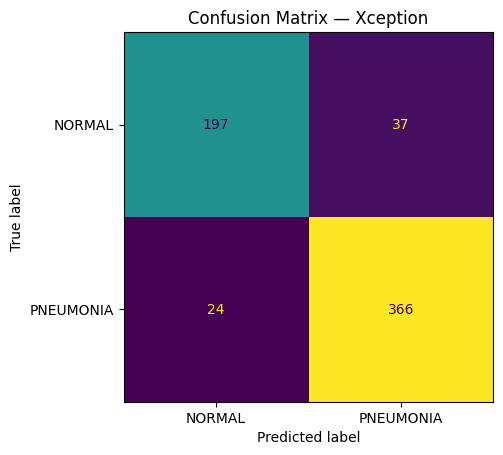

In [ ]:
#Evaluate Xception Model
# Test set accuracy
loss_x, acc_x = model_xception.evaluate(test_generator_rgb)
print(f"Xception test accuracy: {acc_x:.4f}")

# Confusion matrix and metrics
y_pred_x     = np.argmax(model_xception.predict(test_generator_rgb), axis=1)
y_true_x     = test_generator_rgb.classes
cm_x         = confusion_matrix(y_true_x, y_pred_x)

TN_x, FP_x  = cm_x[0, 0], cm_x[0, 1]
FN_x, TP_x  = cm_x[1, 0], cm_x[1, 1]

print(f"Sensitivity: {TP_x / (TP_x + FN_x):.3f}")
print(f"Specificity: {TN_x / (TN_x + FP_x):.3f}")
print(f"Missed pneumonia (FN): {FN_x}")

disp_x = ConfusionMatrixDisplay(confusion_matrix=cm_x,
                                 display_labels=['NORMAL', 'PNEUMONIA'])
disp_x.plot(colorbar=False)
plt.title('Confusion Matrix — Xception')
plt.show()

In [ ]:
#Threshhold tuning to find the clinical operating point
# Use your best model — swap model / test_generator if using Xception
test_generator.reset()
pneumonia_probs = model.predict(test_generator, steps=len(test_generator))[:, 1]

print(f"{'Threshold':>10}  {'Missed (FN)':>12}  {'False alarms (FP)':>18}  {'Sensitivity':>12}  {'Specificity':>12}")
print("-" * 72)

for t in [0.9, 0.7, 0.5, 0.3, 0.1, 0.05]:
    pred = (pneumonia_probs >= t).astype(int)
    fn = ((pred == 0) & (y_true == 1)).sum()
    fp = ((pred == 1) & (y_true == 0)).sum()
    tn = ((pred == 0) & (y_true == 0)).sum()
    tp = ((pred == 1) & (y_true == 1)).sum()
    sens = tp / (tp + fn) if (tp + fn) > 0 else 0
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0
    marker = " ← meets ≤5 FN constraint" if fn <= 5 else ""
    print(f"{t:>10.2f}  {fn:>12}  {fp:>18}  {sens:>12.3f}  {spec:>12.3f}{marker}")

20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 142ms/step
 Threshold   Missed (FN)   False alarms (FP)   Sensitivity   Specificity
------------------------------------------------------------------------
      0.90            52                  22         0.867         0.906
      0.70            21                  39         0.946         0.833
      0.50             9                  75         0.977         0.679
      0.30             4                 113         0.990         0.517 ← meets ≤5 FN constraint
      0.10             1                 179         0.997         0.235 ← meets ≤5 FN constraint
      0.05             0                 209         1.000         0.107 ← meets ≤5 FN constraint
